# FER-2013 — ResNet50 + Dual-Axis Attention + Transformer

In [ ]:
!pip -q install -U mediapipe

In [ ]:
import os, time, json, random, shutil, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from google.colab import drive, files

drive.mount("/content/drive")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type != "cuda":
    raise RuntimeError("Enable a GPU runtime.")

print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch: 2.11.0+cu128
GPU: Tesla T4


In [ ]:
DRIVE_DIR = Path("/content/drive/MyDrive/EmD")
RUN_DIR = DRIVE_DIR / "fer2013_resnet50_dualattn_transformer"
CKPT_DIR = RUN_DIR / "checkpoints"
FIG_DIR = RUN_DIR / "figures"
REPORT_DIR = RUN_DIR / "reports"

for p in [RUN_DIR, CKPT_DIR, FIG_DIR, REPORT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

BEST_CKPT = CKPT_DIR / "best_model.pt"
LATEST_CKPT = CKPT_DIR / "latest_checkpoint.pt"
HISTORY_CSV = REPORT_DIR / "history.csv"

LOCAL_ROOT = Path("/content/fer2013_rda_data")
COPY_TO_LOCAL = True

SEED = 42
IMG_SIZE = 224
VAL_SPLIT = 0.10
BATCH_SIZE = 32
ACCUM_STEPS = 2
NUM_WORKERS = 2

MAX_EPOCHS = 60
EARLY_STOP_PATIENCE = 10
LABEL_SMOOTHING = 0.08
WEIGHT_DECAY = 2e-4
BACKBONE_LR = 1e-5
HEAD_LR = 2e-4
GRAD_CLIP = 1.0

AMP = True
RESUME = True
USE_TTA = True

EMBED_DIM = 512
TRANSFORMER_LAYERS = 3
TRANSFORMER_HEADS = 8
TRANSFORMER_FF = 1536
TRANSFORMER_DROPOUT = 0.20
CLASSIFIER_DROPOUT = 0.50

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

try:
    torch.set_float32_matmul_precision("high")
except:
    pass

print("Run folder:", RUN_DIR)

Run folder: /content/drive/MyDrive/EmD/fer2013_resnet50_dualattn_transformer


In [ ]:
import zipfile
import shutil
from pathlib import Path

ZIP_PATH = Path("/content/drive/MyDrive/EmD/FER-2013.zip")
EXTRACT_DIR = Path("/content/fer2013_extracted")
LOCAL_ROOT = Path("/content/fer2013_rda_data")

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Dataset ZIP not found: {ZIP_PATH}")

# Extract ZIP
if not EXTRACT_DIR.exists():
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

    print("Extracting FER-2013.zip...")

    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)

    print("Extraction complete.")


# Find folder containing train/ and test/
def find_root(base):
    base = Path(base)

    if (base / "train").is_dir() and (base / "test").is_dir():
        return base

    for p in base.rglob("train"):
        if (p.parent / "test").is_dir():
            return p.parent

    return None


src = find_root(EXTRACT_DIR)

if src is None:
    raise FileNotFoundError(
        "Could not find train/ and test/ inside FER-2013.zip"
    )


# Copy to Colab local storage for faster training
LOCAL_ROOT.mkdir(parents=True, exist_ok=True)

if not (LOCAL_ROOT / "train").exists():
    print("Copying train data...")
    shutil.copytree(
        src / "train",
        LOCAL_ROOT / "train",
        dirs_exist_ok=True
    )

if not (LOCAL_ROOT / "test").exists():
    print("Copying test data...")
    shutil.copytree(
        src / "test",
        LOCAL_ROOT / "test",
        dirs_exist_ok=True
    )


DATA_ROOT = LOCAL_ROOT

TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"


base_ds = datasets.ImageFolder(TRAIN_DIR)
test_base = datasets.ImageFolder(TEST_DIR)

class_names = base_ds.classes
targets = np.array(base_ds.targets)
NUM_CLASSES = len(class_names)


display(pd.DataFrame({
    "class": class_names,
    "train_folder": np.bincount(
        targets,
        minlength=NUM_CLASSES
    ),
    "test": np.bincount(
        np.array(test_base.targets),
        minlength=NUM_CLASSES
    )
}))


print("Dataset source:", src)
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR:", TEST_DIR)

print("Train-folder total:", len(base_ds))
print("Test total:", len(test_base))

,class,train_folder,test
0,angry,3995,958
1,disgust,436,111
2,fear,4097,1024
3,happy,7215,1774
4,neutral,4965,1233
5,sad,4830,1247
6,surprise,3171,831


Dataset source: /content/fer2013_extracted
TRAIN_DIR: /content/fer2013_rda_data/train
TEST_DIR: /content/fer2013_rda_data/test
Train-folder total: 28709
Test total: 7178


In [ ]:
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.86, 1.0), ratio=(0.95, 1.05)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10, fill=0),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.12, scale=(0.02, 0.07), ratio=(0.6, 1.7), value="random")
])

eval_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

sss = StratifiedShuffleSplit(n_splits=1, test_size=VAL_SPLIT, random_state=SEED)
train_idx, val_idx = next(sss.split(np.zeros(len(targets)), targets))

train_full = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
val_full = datasets.ImageFolder(TRAIN_DIR, transform=eval_tf)
test_ds = datasets.ImageFolder(TEST_DIR, transform=eval_tf)

train_ds = Subset(train_full, train_idx)
val_ds = Subset(val_full, val_idx)

kw = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=NUM_WORKERS > 0)
train_loader = DataLoader(train_ds, shuffle=True, drop_last=True, **kw)
val_loader = DataLoader(val_ds, shuffle=False, **kw)
test_loader = DataLoader(test_ds, shuffle=False, **kw)

print("Train:", len(train_ds))
print("Validation:", len(val_ds))
print("Test:", len(test_ds))
print("Effective batch:", BATCH_SIZE * ACCUM_STEPS)

Train: 25838
Validation: 2871
Test: 7178
Effective batch: 64


In [ ]:
class DualAxisAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 64)
        self.channel = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, hidden, 1, bias=False),
            nn.GELU(),
            nn.Conv2d(hidden, channels, 1),
            nn.Sigmoid()
        )
        self.spatial = nn.Sequential(
            nn.Conv2d(channels, hidden, 1, bias=False),
            nn.BatchNorm2d(hidden),
            nn.GELU(),
            nn.Conv2d(hidden, 1, 1),
            nn.Sigmoid()
        )
        self.mix = nn.Sequential(
            nn.Conv2d(channels, channels, 1, bias=False),
            nn.BatchNorm2d(channels)
        )

    def forward(self, x):
        xc = x * self.channel(x)
        xs = x * self.spatial(x)
        return x + self.mix(xc + xs)


class EmotionRAT(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        rn = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.backbone = nn.Sequential(*list(rn.children())[:-2])
        self.dual_attention = DualAxisAttention(2048)
        self.proj = nn.Sequential(
            nn.Conv2d(2048, EMBED_DIM, 1, bias=False),
            nn.BatchNorm2d(EMBED_DIM),
            nn.GELU()
        )

        self.cls_token = nn.Parameter(torch.zeros(1, 1, EMBED_DIM))
        self.pos_embed = nn.Parameter(torch.zeros(1, 50, EMBED_DIM))
        self.pos_drop = nn.Dropout(TRANSFORMER_DROPOUT)

        layer = nn.TransformerEncoderLayer(
            d_model=EMBED_DIM,
            nhead=TRANSFORMER_HEADS,
            dim_feedforward=TRANSFORMER_FF,
            dropout=TRANSFORMER_DROPOUT,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(
            layer,
            num_layers=TRANSFORMER_LAYERS,
            norm=nn.LayerNorm(EMBED_DIM)
        )

        self.head = nn.Sequential(
            nn.LayerNorm(EMBED_DIM),
            nn.Dropout(CLASSIFIER_DROPOUT),
            nn.Linear(EMBED_DIM, num_classes)
        )

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        x = self.backbone(x)
        x = self.dual_attention(x)
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = self.pos_drop(x + self.pos_embed[:, :x.size(1)])
        x = self.transformer(x)
        return self.head(x[:, 0])


model = EmotionRAT(NUM_CLASSES).to(DEVICE)
model = model.to(memory_format=torch.channels_last)

print(f"Parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 103MB/s]
/tmp/ipykernel_790/1622331580.py:55: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Parameters: 37.46M


In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

head_params = (
    list(model.dual_attention.parameters()) +
    list(model.proj.parameters()) +
    list(model.transformer.parameters()) +
    list(model.head.parameters()) +
    [model.cls_token, model.pos_embed]
)

optimizer = torch.optim.AdamW([
    {"params": model.backbone.parameters(), "lr": BACKBONE_LR},
    {"params": head_params, "lr": HEAD_LR}
], weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.25, patience=2, min_lr=1e-7
)

try:
    scaler = torch.amp.GradScaler("cuda", enabled=AMP)
except:
    scaler = torch.cuda.amp.GradScaler(enabled=AMP)

def amp_context():
    try:
        return torch.amp.autocast("cuda", dtype=torch.float16, enabled=AMP)
    except:
        return torch.cuda.amp.autocast(enabled=AMP)

In [ ]:
def train_one_epoch():
    model.train()
    optimizer.zero_grad(set_to_none=True)

    total = 0.0
    ys, ps = [], []

    for step, (x, y) in enumerate(train_loader):
        x = x.to(DEVICE, non_blocking=True, memory_format=torch.channels_last)
        y = y.to(DEVICE, non_blocking=True)

        with amp_context():
            logits = model(x)
            loss = criterion(logits, y) / ACCUM_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        total += loss.item() * ACCUM_STEPS * y.size(0)
        ys.extend(y.detach().cpu().numpy())
        ps.extend(logits.argmax(1).detach().cpu().numpy())

    return total / len(train_loader.dataset), accuracy_score(ys, ps), f1_score(ys, ps, average="macro")


@torch.no_grad()
def evaluate(loader, tta=False):
    model.eval()
    total = 0.0
    ys, ps, probs_all = [], [], []

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True, memory_format=torch.channels_last)
        y = y.to(DEVICE, non_blocking=True)

        with amp_context():
            logits = model(x)
            if tta:
                logits = (logits + model(torch.flip(x, dims=[3]))) / 2
            loss = criterion(logits, y)
            probs = torch.softmax(logits, 1)

        total += loss.item() * y.size(0)
        ys.extend(y.cpu().numpy())
        ps.extend(probs.argmax(1).cpu().numpy())
        probs_all.append(probs.cpu().numpy())

    return (
        total / len(loader.dataset),
        accuracy_score(ys, ps),
        f1_score(ys, ps, average="macro"),
        np.asarray(ys),
        np.asarray(ps),
        np.concatenate(probs_all)
    )

In [ ]:
def save_state(path, epoch, best_acc, best_loss, patience_count, history):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "best_val_acc": best_acc,
        "best_val_loss": best_loss,
        "patience_count": patience_count,
        "history": history,
        "class_names": class_names
    }, path)

start_epoch = 0
best_val_acc = 0.0
best_val_loss = float("inf")
patience_count = 0
history = []

if RESUME and LATEST_CKPT.exists():
    ck = torch.load(LATEST_CKPT, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ck["model_state_dict"])
    optimizer.load_state_dict(ck["optimizer_state_dict"])
    scheduler.load_state_dict(ck["scheduler_state_dict"])
    try:
        scaler.load_state_dict(ck["scaler_state_dict"])
    except:
        pass
    start_epoch = ck["epoch"] + 1
    best_val_acc = ck.get("best_val_acc", 0.0)
    best_val_loss = ck.get("best_val_loss", float("inf"))
    patience_count = ck.get("patience_count", 0)
    history = ck.get("history", [])
    print("Resuming from epoch", start_epoch + 1)
else:
    print("Starting new training.")

Starting new training.


In [ ]:
for epoch in range(start_epoch, MAX_EPOCHS):
    t0 = time.time()

    tr_loss, tr_acc, tr_f1 = train_one_epoch()
    va_loss, va_acc, va_f1, _, _, _ = evaluate(val_loader, tta=False)

    scheduler.step(va_loss)

    row = {
        "epoch": epoch + 1,
        "train_loss": tr_loss,
        "train_acc": tr_acc,
        "train_f1": tr_f1,
        "val_loss": va_loss,
        "val_acc": va_acc,
        "val_f1": va_f1,
        "backbone_lr": optimizer.param_groups[0]["lr"],
        "head_lr": optimizer.param_groups[1]["lr"],
        "minutes": (time.time() - t0) / 60
    }
    history.append(row)

    if va_acc > best_val_acc + 1e-5:
        best_val_acc = va_acc
        best_val_loss = va_loss
        patience_count = 0
        save_state(BEST_CKPT, epoch, best_val_acc, best_val_loss, patience_count, history)
        mark = " <-- BEST"
    else:
        patience_count += 1
        mark = ""

    save_state(LATEST_CKPT, epoch, best_val_acc, best_val_loss, patience_count, history)
    pd.DataFrame(history).to_csv(HISTORY_CSV, index=False)

    print(
        f"{epoch+1:02d}/{MAX_EPOCHS} | "
        f"train {tr_acc*100:.2f}% F1 {tr_f1:.4f} loss {tr_loss:.4f} | "
        f"val {va_acc*100:.2f}% F1 {va_f1:.4f} loss {va_loss:.4f} | "
        f"lr {optimizer.param_groups[0]['lr']:.1e}/{optimizer.param_groups[1]['lr']:.1e} | "
        f"{row['minutes']:.1f}m{mark}"
    )

    if epoch + 1 >= 15 and patience_count >= EARLY_STOP_PATIENCE:
        print("Early stopping.")
        break

print("Best validation accuracy:", f"{best_val_acc*100:.2f}%")
print("Best checkpoint:", BEST_CKPT)

01/60 | train 38.16% F1 0.2995 loss 1.6749 | val 45.63% F1 0.3648 loss 1.5009 | lr 1.0e-05/2.0e-04 | 2.7m <-- BEST
02/60 | train 47.97% F1 0.3830 loss 1.4639 | val 51.55% F1 0.4156 loss 1.3865 | lr 1.0e-05/2.0e-04 | 2.5m <-- BEST
03/60 | train 52.56% F1 0.4263 loss 1.3738 | val 54.89% F1 0.4429 loss 1.3314 | lr 1.0e-05/2.0e-04 | 2.7m <-- BEST
04/60 | train 55.05% F1 0.4526 loss 1.3214 | val 57.12% F1 0.4881 loss 1.2826 | lr 1.0e-05/2.0e-04 | 2.7m <-- BEST
05/60 | train 57.70% F1 0.4856 loss 1.2712 | val 57.61% F1 0.4988 loss 1.2772 | lr 1.0e-05/2.0e-04 | 2.6m <-- BEST
06/60 | train 59.41% F1 0.5164 loss 1.2348 | val 58.59% F1 0.5202 loss 1.2460 | lr 1.0e-05/2.0e-04 | 2.6m <-- BEST
07/60 | train 61.41% F1 0.5480 loss 1.1980 | val 60.71% F1 0.5461 loss 1.2165 | lr 1.0e-05/2.0e-04 | 2.7m <-- BEST
08/60 | train 62.71% F1 0.5626 loss 1.1663 | val 61.69% F1 0.5606 loss 1.2012 | lr 1.0e-05/2.0e-04 | 2.7m <-- BEST
09/60 | train 64.25% F1 0.5894 loss 1.1423 | val 61.55% F1 0.5588 loss 1.2116 | 

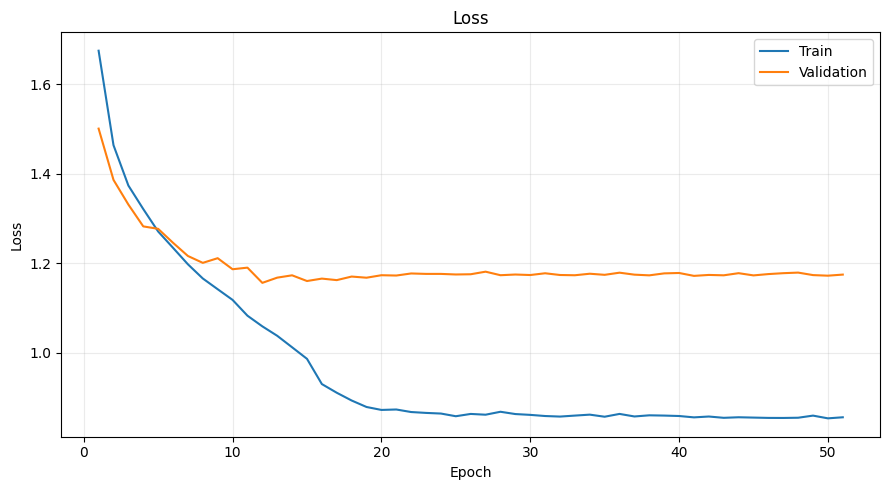

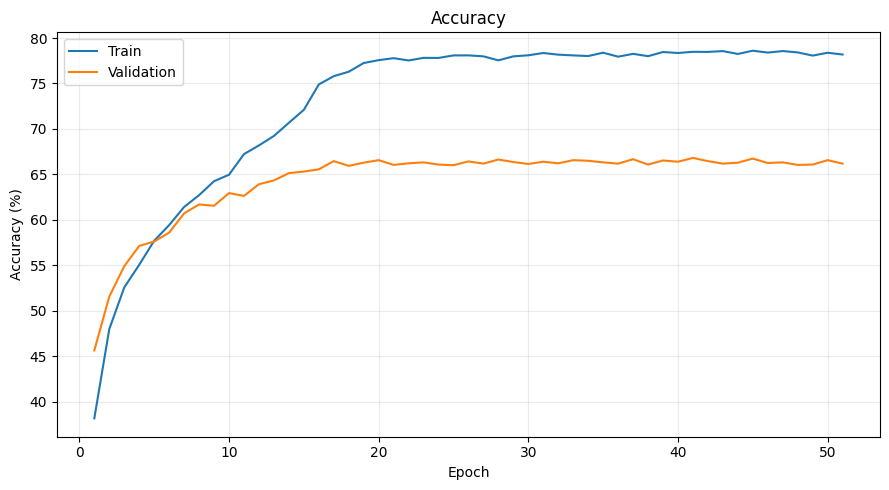

In [ ]:
hist = pd.read_csv(HISTORY_CSV)

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(hist.epoch, hist.train_loss, label="Train")
ax.plot(hist.epoch, hist.val_loss, label="Validation")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title("Loss")
ax.grid(alpha=.25); ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "loss_curve.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(hist.epoch, hist.train_acc*100, label="Train")
ax.plot(hist.epoch, hist.val_acc*100, label="Validation")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)"); ax.set_title("Accuracy")
ax.grid(alpha=.25); ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "accuracy_curve.png", dpi=180)
plt.show()

Best epoch: 41
Test accuracy: 66.94%
Test macro-F1: 0.6476
Balanced accuracy: 0.6394


,precision,recall,f1-score,support
angry,0.580122,0.597077,0.588477,958.000000
disgust,0.714286,0.540541,0.615385,111.000000
fear,0.552663,0.456055,0.499732,1024.000000
happy,0.882387,0.866967,0.874609,1774.000000
neutral,0.581754,0.672344,0.623777,1233.000000
sad,0.541768,0.535686,0.538710,1247.000000
surprise,0.778422,0.807461,0.792676,831.000000
accuracy,0.669407,0.669407,0.669407,0.669407
macro avg,0.661629,0.639447,0.647624,7178.000000
weighted avg,0.669557,0.669407,0.668007,7178.000000


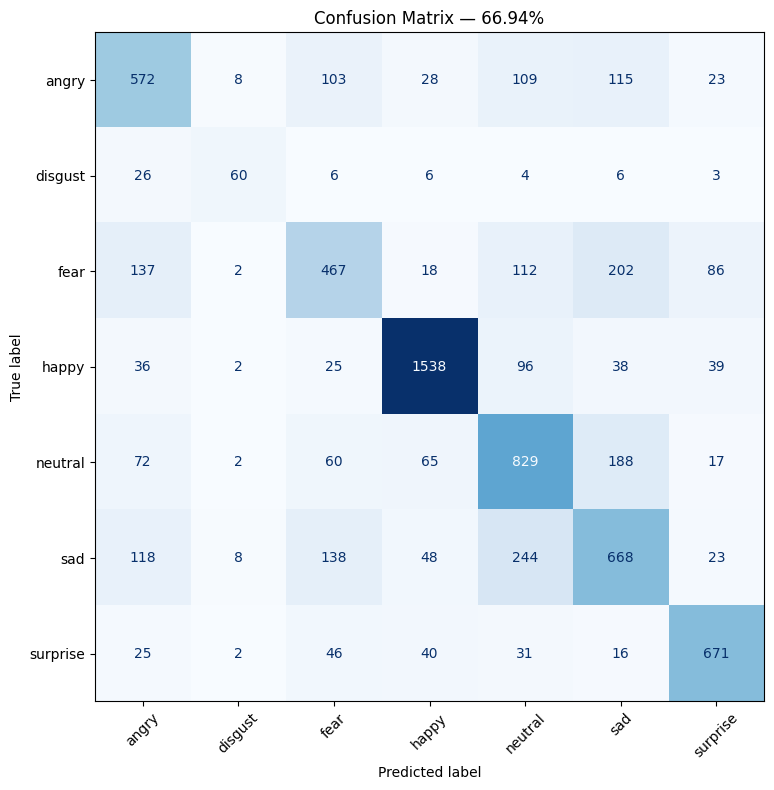

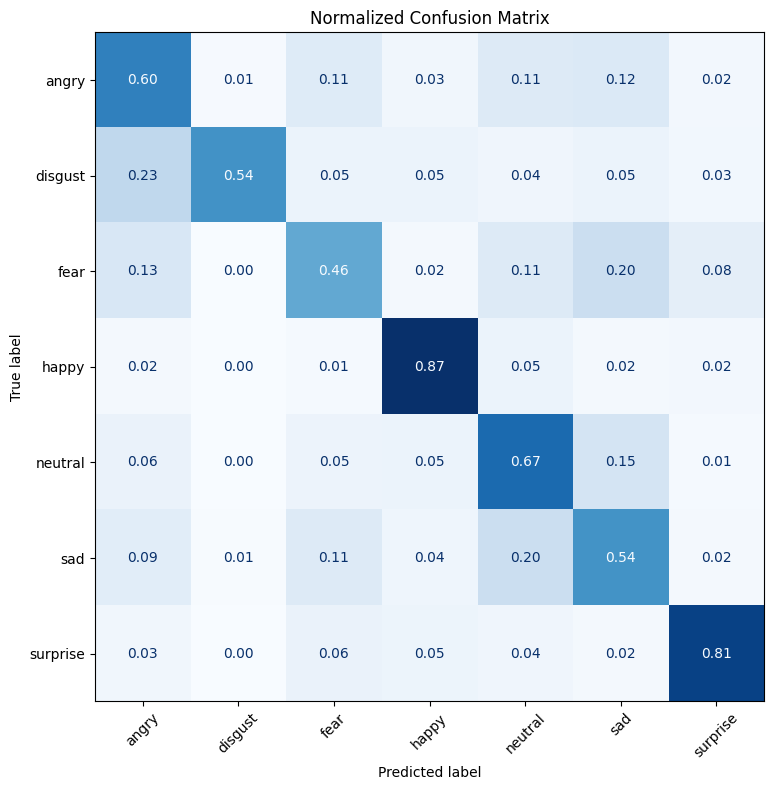

In [ ]:
best = torch.load(BEST_CKPT, map_location=DEVICE, weights_only=False)
model.load_state_dict(best["model_state_dict"])

te_loss, te_acc, te_f1, test_y, test_pred, test_prob = evaluate(test_loader, tta=USE_TTA)
te_bal = balanced_accuracy_score(test_y, test_pred)

print("Best epoch:", best["epoch"] + 1)
print(f"Test accuracy: {te_acc*100:.2f}%")
print(f"Test macro-F1: {te_f1:.4f}")
print(f"Balanced accuracy: {te_bal:.4f}")

report_df = pd.DataFrame(classification_report(
    test_y, test_pred, target_names=class_names, output_dict=True, digits=4
)).T
display(report_df)
report_df.to_csv(REPORT_DIR / "classification_report.csv")

cm = confusion_matrix(test_y, test_pred)
cmn = confusion_matrix(test_y, test_pred, normalize="true")

fig, ax = plt.subplots(figsize=(8,8))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, cmap="Blues", values_format="d", colorbar=False, xticks_rotation=45
)
ax.set_title(f"Confusion Matrix — {te_acc*100:.2f}%")
fig.tight_layout()
fig.savefig(FIG_DIR / "confusion_matrix.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(8,8))
ConfusionMatrixDisplay(cmn, display_labels=class_names).plot(
    ax=ax, cmap="Blues", values_format=".2f", colorbar=False, xticks_rotation=45
)
ax.set_title("Normalized Confusion Matrix")
fig.tight_layout()
fig.savefig(FIG_DIR / "confusion_matrix_normalized.png", dpi=180)
plt.show()

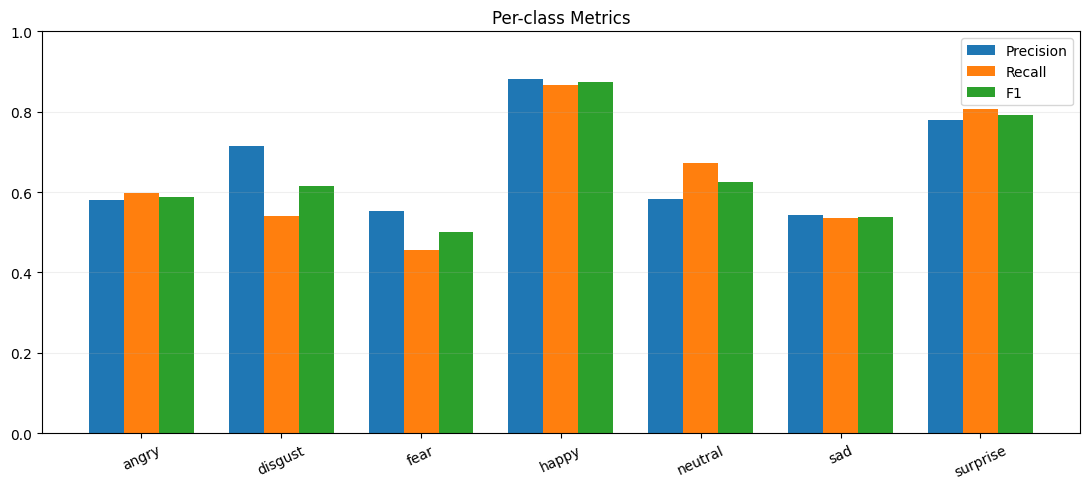

Saved: /content/drive/MyDrive/EmD/fer2013_resnet50_dualattn_transformer


In [ ]:
m = report_df.loc[class_names, ["precision", "recall", "f1-score"]]
x = np.arange(NUM_CLASSES)
w = .25

fig, ax = plt.subplots(figsize=(11,5))
ax.bar(x-w, m["precision"], w, label="Precision")
ax.bar(x, m["recall"], w, label="Recall")
ax.bar(x+w, m["f1-score"], w, label="F1")
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=25)
ax.set_ylim(0,1)
ax.set_title("Per-class Metrics")
ax.legend()
ax.grid(axis="y", alpha=.2)
fig.tight_layout()
fig.savefig(FIG_DIR / "per_class_metrics.png", dpi=180)
plt.show()

torch.save(model.state_dict(), CKPT_DIR / "best_weights_only.pth")

with open(REPORT_DIR / "metadata.json", "w") as f:
    json.dump({
        "architecture": "Independent ResNet50 + DualAxisAttention + Transformer",
        "classes": class_names,
        "best_epoch": int(best["epoch"]) + 1,
        "best_val_accuracy": float(best["best_val_acc"]),
        "test_accuracy": float(te_acc),
        "test_macro_f1": float(te_f1),
        "balanced_accuracy": float(te_bal),
        "tta": bool(USE_TTA)
    }, f, indent=2)

print("Saved:", RUN_DIR)